<a href="https://colab.research.google.com/github/antonioemsac/Indice-de-Competitividad-Economica-Municipal-Istmo-de-Tehuantepec-Oaxaca/blob/main/An%C3%A1lisis_de_estructura_econ%C3%B3mica_municipal_diversidad%2C_concentraci%C3%B3n_y_potencial_de_proveedur%C3%ADa_industrial_en_Oaxaca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

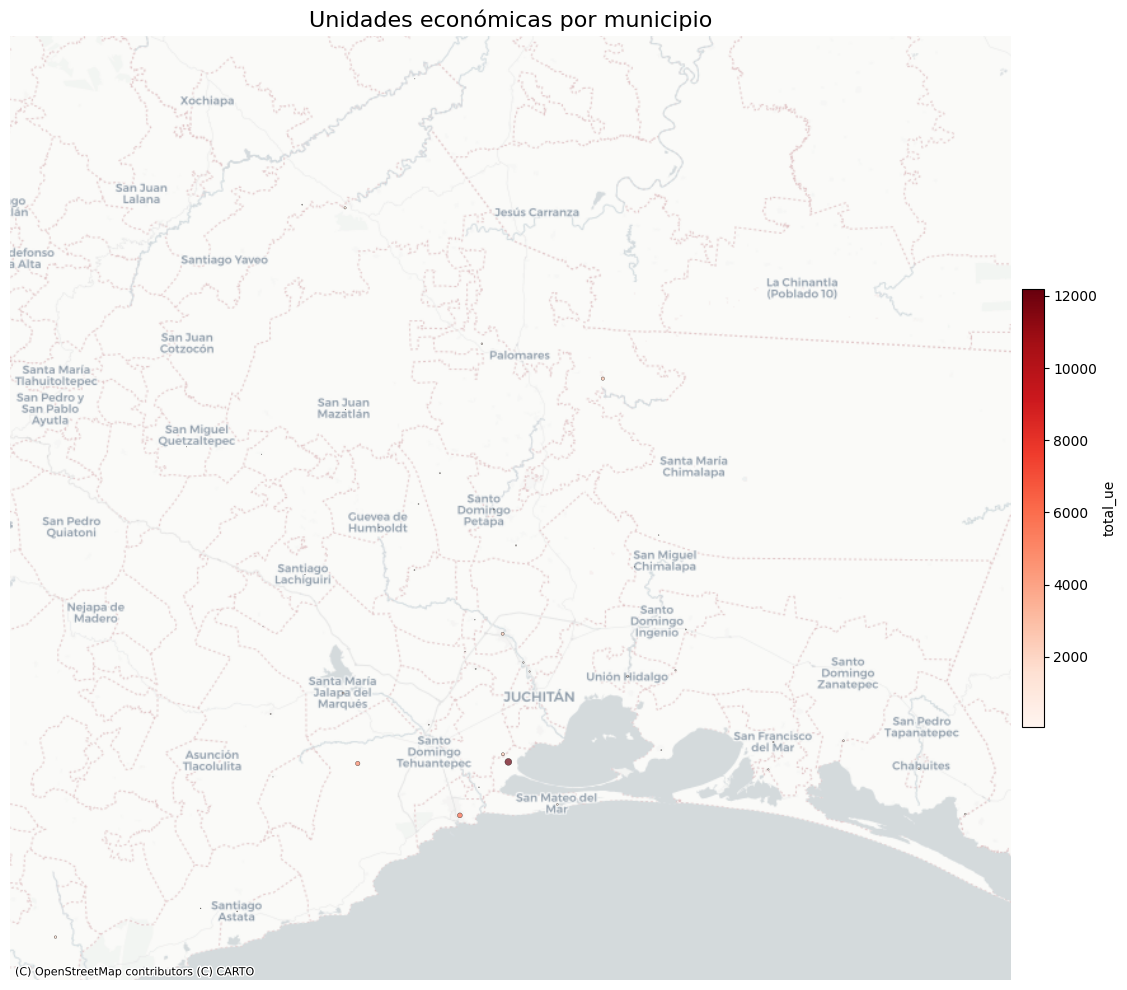

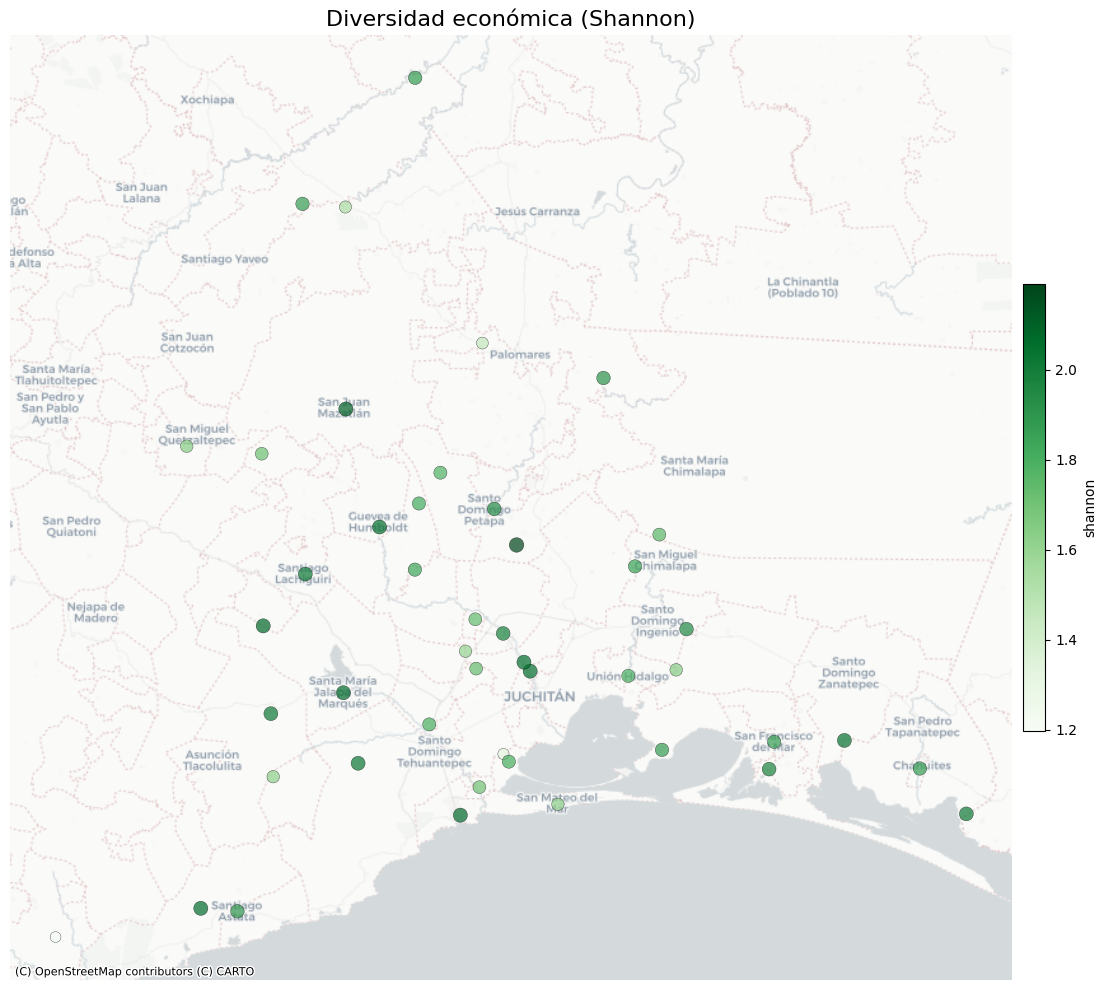

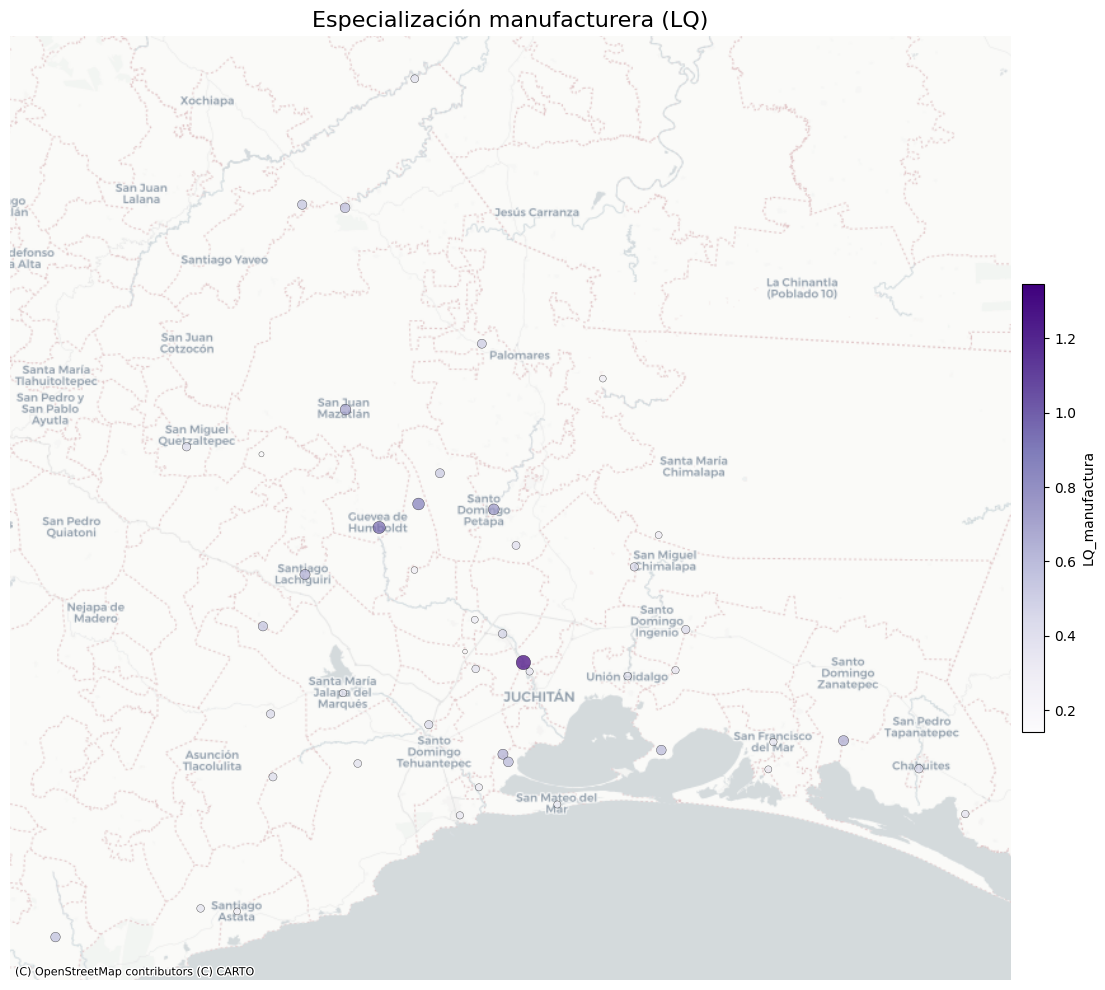

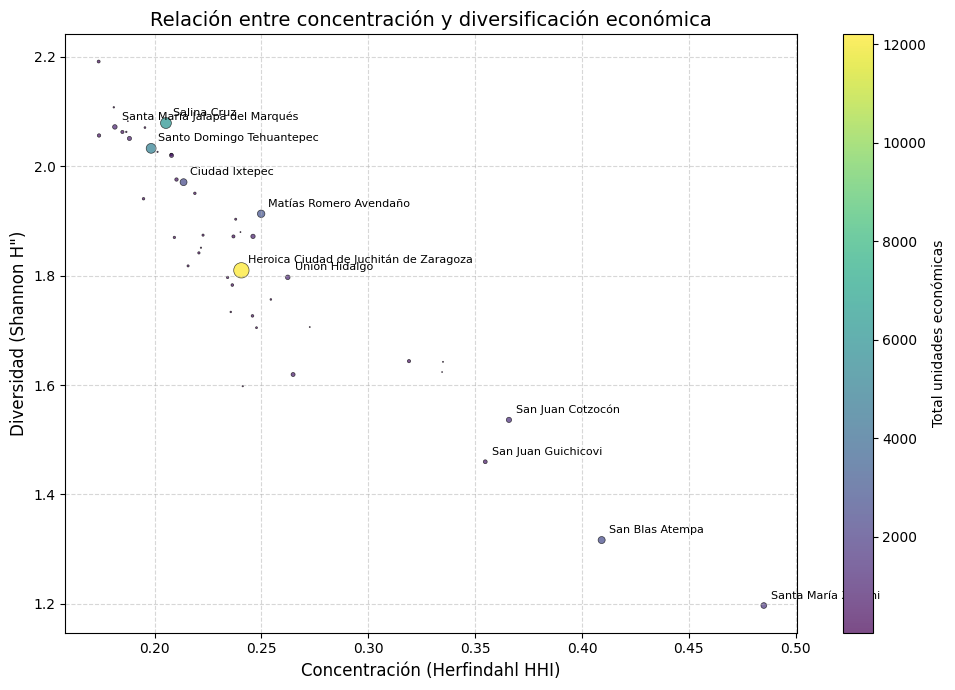

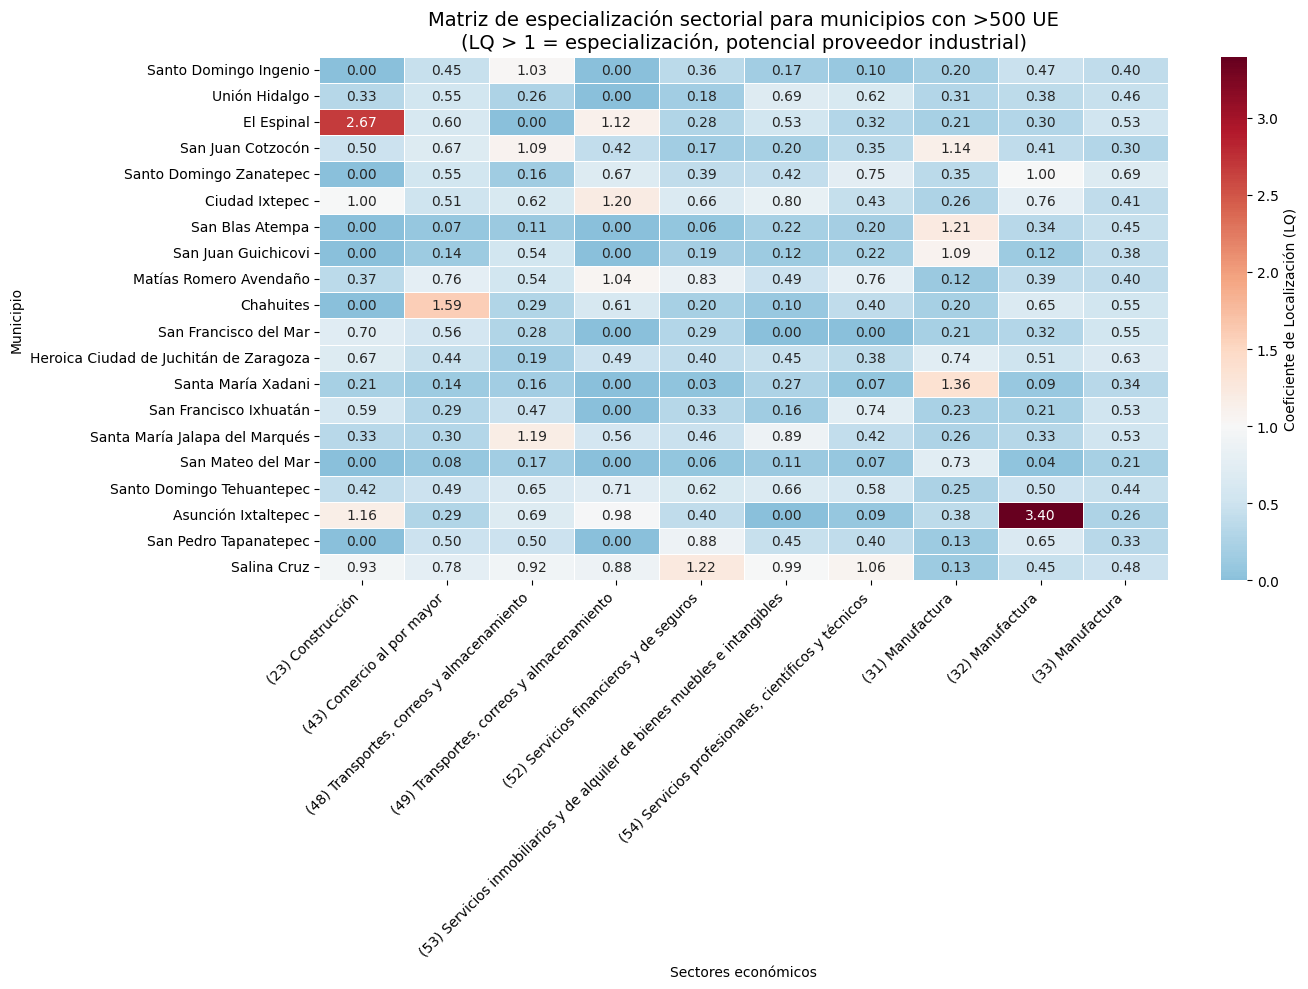

✅ Todos los gráficos se han generado y guardado en la carpeta actual.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point
import contextily as ctx
import warnings
warnings.filterwarnings('ignore')

# Define the file_path variable
file_path = '/content/Municipios CIIT.xlsx'

df_ue = pd.read_excel(file_path, sheet_name='Municipios de Oaxaca')

df_ue.columns = [c.strip() for c in df_ue.columns]
df_ue.rename(columns={'MUNICIPIO': 'municipio', 'TOTAL': 'total_ue'}, inplace=True)


sector_cols = df_ue.columns[2:25]
if 'TOTAL' in sector_cols:
    sector_cols = sector_cols.drop('TOTAL')
df_ue[sector_cols] = df_ue[sector_cols].apply(pd.to_numeric, errors='coerce').fillna(0)


for col in sector_cols:
    df_ue[f'prop_{col}'] = df_ue[col] / df_ue['total_ue'].replace(0, np.nan)


regional_prop = df_ue[sector_cols].sum() / df_ue['total_ue'].sum()

for col in sector_cols:
    df_ue[f'LQ_{col}'] = (df_ue[col] / df_ue['total_ue']) / regional_prop[col]


def shannon(row, sectors):
    p = row[[f'prop_{s}' for s in sectors]].fillna(0)
    p = p[p > 0]
    return -np.sum(p * np.log(p)) if len(p) > 0 else 0
df_ue['shannon'] = df_ue.apply(lambda r: shannon(r, sector_cols), axis=1)

# Índice de Herfindahl (concentración)
def herfindahl(row, sectors):
    p = row[[f'prop_{s}' for s in sectors]].fillna(0)
    return np.sum(p**2)
df_ue['hhi'] = df_ue.apply(lambda r: herfindahl(r, sector_cols), axis=1)

# LQ Manufacturero (promedio de LQ de (31), (32), (33))
manufactura_cols = ['(31) Industrias manufactureras', '(32) Industrias manufactureras', '(33) Industrias manufactureras']
manufactura_cols = [c for c in manufactura_cols if c in df_ue.columns]
df_ue['LQ_manufactura'] = df_ue[[f'LQ_{c}' for c in manufactura_cols]].mean(axis=1)

# Nombre limpio del municipio (sin clave)
df_ue['municipio_limpio'] = df_ue['municipio'].str.replace(r'^\(\d+\)\s*', '', regex=True)

# ============================
# MAPAS COROPLÉTICOS (con centroides)
# ============================
# Crear geometría de puntos a partir de Latitud y Longitud
gdf = df_ue.dropna(subset=['Latitud', 'Longitud']).copy()
geometry = [Point(xy) for xy in zip(gdf['Longitud'], gdf['Latitud'])]
gdf = gpd.GeoDataFrame(gdf, geometry=geometry, crs='EPSG:4326')
gdf = gdf.to_crs(epsg=3857)  # Web Mercator para fondo de mapa

def plot_choropleth_bubbles(gdf, column, title, cmap='Reds', size_factor=1):
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    # Normalizar color
    norm = plt.Normalize(gdf[column].min(), gdf[column].max())
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    # Dibujar burbujas con tamaño proporcional al valor (opcional)
    gdf.plot(ax=ax, marker='o', markersize=gdf[column]*size_factor,
             color=[sm.to_rgba(v) for v in gdf[column]], alpha=0.7, edgecolor='black', linewidth=0.3)
    ax.set_title(title, fontsize=16)
    ax.set_axis_off()
    cbar = plt.colorbar(sm, ax=ax, fraction=0.02, pad=0.01)
    cbar.set_label(column)
    ctx.add_basemap(ax, crs=gdf.crs, source=ctx.providers.CartoDB.Positron)
    plt.tight_layout()
    plt.savefig(f'{title.replace(' ', '_')}.png', dpi=300)
    plt.show()

# Mapa 1: Número de unidades económicas
plot_choropleth_bubbles(gdf, 'total_ue', 'Unidades económicas por municipio', cmap='Reds', size_factor=0.002)

# Mapa 2: Diversidad económica (Shannon)
plot_choropleth_bubbles(gdf, 'shannon', 'Diversidad económica (Shannon)', cmap='Greens', size_factor=50)

# Mapa 3: Especialización manufacturera (LQ)
plot_choropleth_bubbles(gdf, 'LQ_manufactura', 'Especialización manufacturera (LQ)', cmap='Purples', size_factor=80)

# ============================
# DIAGRAMA DE DISPERSIÓN (Concentración vs Diversidad)
# ============================
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(df_ue['hhi'], df_ue['shannon'],
                     c=df_ue['total_ue'], s=df_ue['total_ue']/100,
                     cmap='viridis', alpha=0.7, edgecolors='black', linewidth=0.5)
# Etiquetar municipios destacados
for _, row in df_ue.iterrows():
    if row['total_ue'] > 1000 or row['hhi'] > 0.4 or row['shannon'] < 1.5:
        ax.annotate(row['municipio_limpio'], (row['hhi'], row['shannon']),
                    fontsize=8, xytext=(5,5), textcoords='offset points')
ax.set_xlabel('Concentración (Herfindahl HHI)', fontsize=12)
ax.set_ylabel('Diversidad (Shannon H")', fontsize=12)
ax.set_title('Relación entre concentración y diversificación económica', fontsize=14)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Total unidades económicas')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('dispersión_concentracion_diversidad.png', dpi=300)
plt.show()

# ============================
# MATRIZ DE LOCALIZACIÓN (potencial de proveeduría industrial)
# ============================
# Sectores clave para proveer insumos a parques industriales
sectores_proveeduria = [
    '(23) Construcción',
    '(43) Comercio al por mayor',
    '(48) Transportes, correos y almacenamiento',
    '(49) Transportes, correos y almacenamiento',
    '(52) Servicios financieros y de seguros',
    '(53) Servicios inmobiliarios y de alquiler de bienes muebles e intangibles',
    '(54) Servicios profesionales, científicos y técnicos',
    '(56) Servicios de apoyo a los negocios y manejo de desechos',
    '(31) Industrias manufactureras',
    '(32) Industrias manufactureras',
    '(33) Industrias manufactureras'
]
sectores_proveeduria = [s for s in sectores_proveeduria if s in df_ue.columns]

# Filtrar municipios con más de 500 UE (potencial económico relevante)
df_potencial = df_ue[df_ue['total_ue'] > 500].copy()
matrix_lq = df_potencial[['municipio_limpio'] + [f'LQ_{s}' for s in sectores_proveeduria]].set_index('municipio_limpio')
# Renombrar columnas para legibilidad
matrix_lq.columns = [c.replace('LQ_', '').replace('Industrias manufactureras', 'Manufactura') for c in matrix_lq.columns]

# Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(matrix_lq, annot=True, fmt='.2f', cmap='RdBu_r', center=1,
            linewidths=0.5, cbar_kws={'label': 'Coeficiente de Localización (LQ)'})
plt.title('Matriz de especialización sectorial para municipios con >500 UE\n(LQ > 1 = especialización, potencial proveedor industrial)', fontsize=14)
plt.xlabel('Sectores económicos')
plt.ylabel('Municipio')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('matriz_localizacion_proveeduria.png', dpi=300)
plt.show()

print("✅ Todos los gráficos se han generado y guardado en la carpeta actual.")

In [ ]:
Como bajar los gráficos?


SyntaxError: invalid syntax (1911913678.py, line 1)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Cómo subir archivos a Google Colab:

1.  **Usando el panel de archivos de Colab (la forma más fácil):**
    *   En el lado izquierdo de tu notebook de Colab, verás un icono de una carpeta (📁). Haz clic en él.
    *   Esto abrirá el panel de archivos. En la parte superior de este panel, hay un icono con una flecha hacia arriba (⬆️). Haz clic en él.
    *   Se abrirá una ventana para que puedas seleccionar archivos de tu computadora. Navega hasta donde esté tu archivo `Municipios CIIT.xlsx`, selecciónalo y haz clic en 'Abrir' o 'Cargar'.
    *   Una vez cargado, el archivo aparecerá en la raíz de tu entorno de Colab (`/content/`).

2.  **Usando código Python:**
    Si prefieres usar código, puedes ejecutar la siguiente celda y se te pedirá que elijas un archivo:

    ```python
    from google.colab import files
    uploaded = files.upload()

    for fn in uploaded.keys():
      print('User uploaded file "{name}" with length {length} bytes'.format(
          name=fn, length=len(uploaded[fn])))
    ```

Después de subir tu archivo, asegúrate de que el `file_path` en tu código sea correcto, que en este caso debería ser `/content/Municipios CIIT.xlsx`.